In [2]:
# Analisis Exploratorio

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv(
    'GRD.csv',
    encoding='latin-1',
    engine='python',            # use python parser which is more forgiving         
    sep=';'                 # uncomment/adjust if the file uses a different separator
)

df.head()

,COD_HOSPITAL,ID_BENEFICIARIO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,...,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,107102,77447810,MUJER,18/9/1939,NINGUNO,MARGA MARGA,VILLA ALEMANA,CHILE,FONASA INSTITUCIONAL - (MAI) B,VIÑA DEL MAR QUILLOTA,...,NaN,23/3/2024,OFTALMOLOGÍA,71043147,1.0,22360,"0,4384",0,0,NaN
1,107100,81269680,MUJER,31/5/1952,NINGUNO,VALPARAISO,VIÑA DEL MAR,CHILE,FONASA INSTITUCIONAL - (MAI) D,VIÑA DEL MAR QUILLOTA,...,NaN,NaN,NaN,78588090,NaN,41023,"58,207",3,3,NaN
2,105101,77590791,HOMBRE,17/7/2012,NINGUNO,ELQUI,LA SERENA,CHILE,FONASA INSTITUCIONAL - (MAI) A,COQUIMBO,...,NaN,26/1/2024,"CIRUGÍA DE CABEZA, CUELLO Y MAXILOFACIAL",75735052,2.0,34141,"0,4462",1,1,HOSPITAL SAN PABLO (COQUIMBO)
3,112100,77589537,HOMBRE,3/11/1952,NINGUNO,SANTIAGO,ÑUÑOA,CHILE,FONASA INSTITUCIONAL - (MAI) D,METROPOLITANO ORIENTE,...,NaN,8/4/2024,UROLOGÍA,83828813,1.0,61203,"35,647",3,3,NaN
4,118100,94523630,MUJER,28/2/1994,NINGUNO,CONCEPCION,SAN PEDRO DE LA PAZ,PERÚ,FONASA INSTITUCIONAL - (MAI) C,CONCEPCIÓN,...,NaN,24/9/2024,CIRUGÍA GENERAL,98438434,1.0,61131,"0,7398",1,1,NaN


In [5]:
df.describe()

,COD_HOSPITAL,CONDICIONDEALTANEONATO1,PESORN1,RN1ESTADO,CONDICIONDEALTANEONATO2,PESORN2,RN2ESTADO,CONDICIONDEALTANEONATO3,PESORN3,RN3ESTADO,...,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,FECHAPROCEDIMIENTO1,MEDICOALTA_ENCRIPTADO,USOSPABELLON
count,1.048575e+06,0.0,115509.000000,94465.000000,0.0,1271.000000,1271.000000,0.0,14.000000,14.000000,...,31350.000000,27361.000000,23976.000000,21006.000000,18246.000000,15998.000000,5.965560e+05,0.0,1.048575e+06,632588.000000
mean,1.145591e+05,NaN,3165.667446,9.050410,NaN,2247.132179,8.597168,NaN,1669.857143,7.571429,...,87.950017,87.984653,87.937450,87.863337,88.050582,87.678529,8.186836e+07,NaN,8.332225e+07,1.388148
std,1.078535e+04,NaN,668.603935,1.066989,NaN,622.546909,1.712334,NaN,612.614555,2.651974,...,18.119481,18.110664,18.078913,18.215817,17.824472,18.591029,9.368093e+06,NaN,9.589202e+06,0.863163
min,1.011000e+05,NaN,100.000000,0.000000,NaN,200.000000,0.000000,NaN,100.000000,0.000000,...,0.140000,0.130000,0.090000,0.120000,0.090000,0.120000,6.698964e+07,NaN,6.698964e+07,0.000000
25%,1.091000e+05,NaN,2855.000000,9.000000,NaN,1902.500000,9.000000,NaN,1545.000000,8.000000,...,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,7.366486e+07,NaN,7.515274e+07,1.000000
50%,1.141010e+05,NaN,3250.000000,9.000000,NaN,2330.000000,9.000000,NaN,1845.000000,8.500000,...,91.390000,91.390000,91.390000,91.390000,91.350000,91.330000,8.075476e+07,NaN,8.269954e+07,1.000000
75%,1.181050e+05,NaN,3590.000000,9.000000,NaN,2687.500000,9.000000,NaN,2055.000000,9.000000,...,96.390000,96.350000,96.350000,96.350000,96.350000,96.350000,8.763694e+07,NaN,9.167102e+07,1.000000
max,2.007170e+05,NaN,9730.000000,11.000000,NaN,3960.000000,10.000000,NaN,2315.000000,10.000000,...,99.940000,99.980000,99.990000,99.840000,99.980000,99.840000,1.022333e+08,NaN,1.022985e+08,8.000000


In [6]:
# 1. Eliminar columnas que solo tienen valores NaN
df1 = df.dropna(axis=1, how='all').copy()

# 2. USOSPABELLON: NaN -> 0
df1['USOSPABELLON'] = df1['USOSPABELLON'].fillna(0)

# 3. HOSPPROCEDENCIA (hospital de procedencia): NaN -> "sin especificar"
df1['HOSPPROCEDENCIA'] = df1['HOSPPROCEDENCIA'].fillna('SIN ESPECIFICAR')



# 5. Verificar nulos restantes
nulos = df1.isnull().sum()
print('Columnas eliminadas (solo NaN):', set(df.columns) - set(df1.columns))
print('\nNulos restantes:')
print(nulos[nulos > 0])
df1.head(50)

Columnas eliminadas (solo NaN): {'FECHAPROCEDIMIENTO1', 'SEXORN4', 'CONDICIONDEALTANEONATO3', 'CONDICIONDEALTANEONATO1', 'PESORN4', 'CONDICIONDEALTANEONATO4', 'RN4ESTADO', 'CONDICIONDEALTANEONATO2'}

Nulos restantes:
FECHATRASLADO1               881065
SERVICIOTRASLADO1            881065
FECHATRASLADO2               993319
SERVICIOTRASLADO2            993319
FECHATRASLADO3              1032002
                             ...   
PROCEDIMIENTO29             1030329
PROCEDIMIENTO30             1032577
MEDICOINTERV1_ENCRIPTADO     452019
FECHAINTERV1                 519451
ESPECIALIDADINTERVENCION     450434
Length: 94, dtype: int64


,COD_HOSPITAL,ID_BENEFICIARIO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,...,MEDICOINTERV1_ENCRIPTADO,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,107102,77447810,MUJER,18/9/1939,NINGUNO,MARGA MARGA,VILLA ALEMANA,CHILE,FONASA INSTITUCIONAL - (MAI) B,VIÑA DEL MAR QUILLOTA,...,71043147.0,23/3/2024,OFTALMOLOGÍA,71043147,1.0,22360,"0,4384",0,0,SIN ESPECIFICAR
1,107100,81269680,MUJER,31/5/1952,NINGUNO,VALPARAISO,VIÑA DEL MAR,CHILE,FONASA INSTITUCIONAL - (MAI) D,VIÑA DEL MAR QUILLOTA,...,NaN,NaN,NaN,78588090,0.0,41023,"58,207",3,3,SIN ESPECIFICAR
2,105101,77590791,HOMBRE,17/7/2012,NINGUNO,ELQUI,LA SERENA,CHILE,FONASA INSTITUCIONAL - (MAI) A,COQUIMBO,...,71831896.0,26/1/2024,"CIRUGÍA DE CABEZA, CUELLO Y MAXILOFACIAL",75735052,2.0,34141,"0,4462",1,1,HOSPITAL SAN PABLO (COQUIMBO)
3,112100,77589537,HOMBRE,3/11/1952,NINGUNO,SANTIAGO,ÑUÑOA,CHILE,FONASA INSTITUCIONAL - (MAI) D,METROPOLITANO ORIENTE,...,80215470.0,8/4/2024,UROLOGÍA,83828813,1.0,61203,"35,647",3,3,SIN ESPECIFICAR
4,118100,94523630,MUJER,28/2/1994,NINGUNO,CONCEPCION,SAN PEDRO DE LA PAZ,PERÚ,FONASA INSTITUCIONAL - (MAI) C,CONCEPCIÓN,...,98438434.0,24/9/2024,CIRUGÍA GENERAL,98438434,1.0,61131,"0,7398",1,1,SIN ESPECIFICAR
5,119101,77290150,MUJER,31/5/1983,NINGUNO,CONCEPCION,TOME,CHILE,FONASA INSTITUCIONAL - (MAI) D,TALCAHUANO,...,83916331.0,5/1/2024,OBSTETRICIA Y GINECOLOGÍA,83916331,1.0,132210,"0,9538",0,0,SIN ESPECIFICAR
6,118100,68254315,MUJER,12/1/1967,NINGUNO,CONCEPCION,CONCEPCIÓN,CHILE,FONASA INSTITUCIONAL - (MAI) D,CONCEPCIÓN,...,NaN,NaN,NaN,98438434,3.0,74143,"11,495",3,2,SIN ESPECIFICAR
7,108100,79566233,HOMBRE,4/12/1950,NINGUNO,SAN FELIPE,SAN FELIPE,CHILE,FONASA LIBRE ELECCIÓN (FMLE_B),ACONCAGUA,...,68461249.0,31/8/2024,CIRUGÍA GENERAL,68461249,1.0,62140,"0,6255",0,0,SIN ESPECIFICAR
8,126100,73275789,MUJER,21/7/1970,NINGUNO,MAGALLANES,PUNTA ARENAS,CHILE,FONASA INSTITUCIONAL - (MAI) B,MAGALLANES,...,74233756.0,3/1/2024,OBSTETRICIA Y GINECOLOGÍA,77262812,1.0,131301,"0,6406",1,1,HOSPITAL DR. LAUTARO NAVARRO AVARIA (PUNTA ARE...
9,126100,73300811,MUJER,8/1/1997,NINGUNO,MAGALLANES,PUNTA ARENAS,CHILE,FONASA INSTITUCIONAL - (MAI) D,MAGALLANES,...,NaN,NaN,NaN,69641433,0.0,134151,"0,1799",1,1,HOSPITAL DR. LAUTARO NAVARRO AVARIA (PUNTA ARE...


In [7]:
df1.describe()

,COD_HOSPITAL,PESORN1,RN1ESTADO,PESORN2,RN2ESTADO,PESORN3,RN3ESTADO,PROCEDIMIENTO8,PROCEDIMIENTO9,PROCEDIMIENTO11,...,PROCEDIMIENTO24,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,MEDICOALTA_ENCRIPTADO,USOSPABELLON
count,1.048575e+06,115509.000000,94465.000000,1271.000000,1271.000000,14.000000,14.000000,465873.000000,395029.000000,275113.000000,...,35735.000000,31350.000000,27361.000000,23976.000000,21006.000000,18246.000000,15998.000000,5.965560e+05,1.048575e+06,1.048575e+06
mean,1.145591e+05,3165.667446,9.050410,2247.132179,8.597168,1669.857143,7.571429,89.527364,89.410667,89.039959,...,87.922747,87.950017,87.984653,87.937450,87.863337,88.050582,87.678529,8.186836e+07,8.332225e+07,8.374470e-01
std,1.078535e+04,668.603935,1.066989,622.546909,1.712334,612.614555,2.651974,16.099474,16.001431,16.333620,...,18.283567,18.119481,18.110664,18.078913,18.215817,17.824472,18.591029,9.368093e+06,9.589202e+06,9.542849e-01
min,1.011000e+05,100.000000,0.000000,200.000000,0.000000,100.000000,0.000000,0.090000,0.010000,0.010000,...,0.120000,0.140000,0.130000,0.090000,0.120000,0.090000,0.120000,6.698964e+07,6.698964e+07,0.000000e+00
25%,1.091000e+05,2855.000000,9.000000,1902.500000,9.000000,1545.000000,8.000000,89.520000,89.520000,89.520000,...,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,7.366486e+07,7.515274e+07,0.000000e+00
50%,1.141010e+05,3250.000000,9.000000,2330.000000,9.000000,1845.000000,8.500000,91.390000,91.390000,91.390000,...,91.390000,91.390000,91.390000,91.390000,91.390000,91.350000,91.330000,8.075476e+07,8.269954e+07,1.000000e+00
75%,1.181050e+05,3590.000000,9.000000,2687.500000,9.000000,2055.000000,9.000000,99.190000,99.180000,97.690000,...,96.570000,96.390000,96.350000,96.350000,96.350000,96.350000,96.350000,8.763694e+07,9.167102e+07,1.000000e+00
max,2.007170e+05,9730.000000,11.000000,3960.000000,10.000000,2315.000000,10.000000,99.990000,99.990000,99.990000,...,99.980000,99.940000,99.980000,99.990000,99.840000,99.980000,99.840000,1.022333e+08,1.022985e+08,8.000000e+00


In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Columns: 121 entries, COD_HOSPITAL to HOSPPROCEDENCIA
dtypes: float64(28), int64(2), object(91)
memory usage: 968.0+ MB


In [9]:
df_maestras = pd.read_excel('Tablas maestras bases GRD.xlsx')
df1['COD_HOSPITAL'] = df1['COD_HOSPITAL'].astype(str).str.strip()
df_maestras['COD_HOSPITAL'] = df_maestras['COD_HOSPITAL'].astype(str).str.strip()

df_final = df1.merge(df_maestras[['COD_HOSPITAL', 'NOM_HOSPITAL']], on='COD_HOSPITAL', how='left')

In [10]:
df_final.head()

,COD_HOSPITAL,ID_BENEFICIARIO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,...,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA,NOM_HOSPITAL
0,107102,77447810,MUJER,18/9/1939,NINGUNO,MARGA MARGA,VILLA ALEMANA,CHILE,FONASA INSTITUCIONAL - (MAI) B,VIÑA DEL MAR QUILLOTA,...,23/3/2024,OFTALMOLOGÍA,71043147,1.0,22360,"0,4384",0,0,SIN ESPECIFICAR,Hospital de Quilpué
1,107100,81269680,MUJER,31/5/1952,NINGUNO,VALPARAISO,VIÑA DEL MAR,CHILE,FONASA INSTITUCIONAL - (MAI) D,VIÑA DEL MAR QUILLOTA,...,NaN,NaN,78588090,0.0,41023,"58,207",3,3,SIN ESPECIFICAR,Hospital Dr. Gustavo Fricke (Viña del Mar)
2,105101,77590791,HOMBRE,17/7/2012,NINGUNO,ELQUI,LA SERENA,CHILE,FONASA INSTITUCIONAL - (MAI) A,COQUIMBO,...,26/1/2024,"CIRUGÍA DE CABEZA, CUELLO Y MAXILOFACIAL",75735052,2.0,34141,"0,4462",1,1,HOSPITAL SAN PABLO (COQUIMBO),Hospital San Pablo (Coquimbo)
3,112100,77589537,HOMBRE,3/11/1952,NINGUNO,SANTIAGO,ÑUÑOA,CHILE,FONASA INSTITUCIONAL - (MAI) D,METROPOLITANO ORIENTE,...,8/4/2024,UROLOGÍA,83828813,1.0,61203,"35,647",3,3,SIN ESPECIFICAR,"Hospital Del Salvador (Santiago, Providencia)"
4,118100,94523630,MUJER,28/2/1994,NINGUNO,CONCEPCION,SAN PEDRO DE LA PAZ,PERÚ,FONASA INSTITUCIONAL - (MAI) C,CONCEPCIÓN,...,24/9/2024,CIRUGÍA GENERAL,98438434,1.0,61131,"0,7398",1,1,SIN ESPECIFICAR,Hospital Clínico Regional Dr. Guillermo Grant ...


In [11]:
# Agrupar por sexo, nombre del hospital y severidad
resumen = df_final.groupby(['SEXO', 'PROVINCIA', 'IR_29301_SEVERIDAD']).size().reset_index(name='TOTAL_CASOS')

# Ordenar los resultados para que sea más fácil de leer
resumen = resumen.sort_values(by=['PROVINCIA', 'TOTAL_CASOS'], ascending=[True, False])

# Guardar el resumen en un nuevo CSV
resumen.to_csv('resumen_grd.csv', index=False)

print(resumen.head())

       SEXO PROVINCIA IR_29301_SEVERIDAD  TOTAL_CASOS
264   MUJER     AISEN                  2          559
36   HOMBRE     AISEN                  2          431
35   HOMBRE     AISEN                  1          318
263   MUJER     AISEN                  1          294
37   HOMBRE     AISEN                  3          137


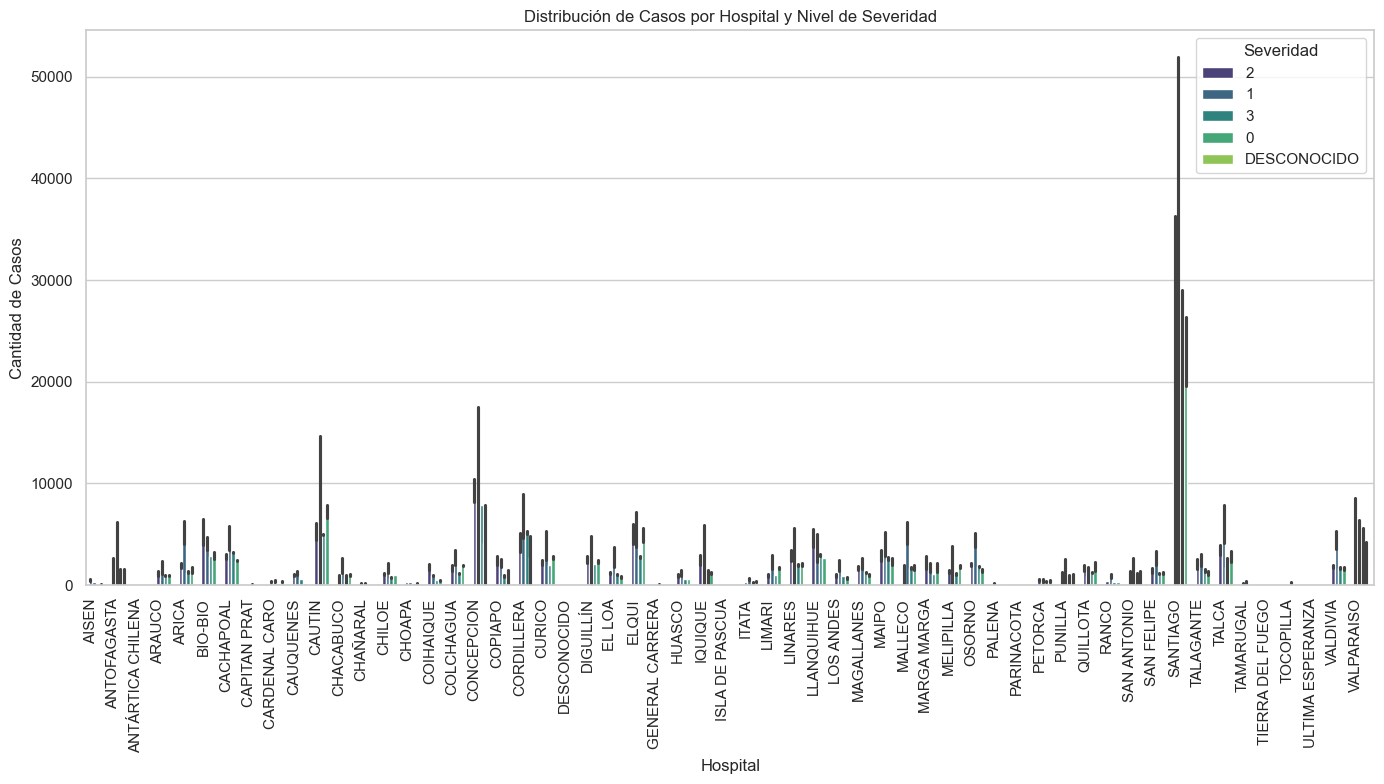

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# Crear gráfico de barras (Hospital vs Casos, separado por Severidad)
ax = sns.barplot(
    data=resumen, 
    x='PROVINCIA', 
    y='TOTAL_CASOS', 
    hue='IR_29301_SEVERIDAD',
    palette='viridis'
)

# Ajustes visuales
plt.xticks(rotation=90, ha='right')
plt.title('Distribución de Casos por Hospital y Nivel de Severidad')
plt.xlabel('Hospital')
plt.ylabel('Cantidad de Casos')
plt.legend(title='Severidad')
plt.tight_layout()

# Guardar y mostrar
plt.savefig('grafico_grd_severidad.png')
plt.show()

# Analisis de tendencia

In [16]:
print(list(df_final.columns))

['COD_HOSPITAL', 'ID_BENEFICIARIO', 'SEXO', 'FECHA_NACIMIENTO', 'ETNIA', 'PROVINCIA', 'COMUNA', 'NACIONALIDAD', 'PREVISION', 'SERVICIO_SALUD', 'TIPO_PROCEDENCIA', 'TIPO_INGRESO', 'ESPECIALIDAD_MEDICA', 'TIPO_ACTIVIDAD', 'FECHA_INGRESO', 'SERVICIOINGRESO', 'FECHATRASLADO1', 'SERVICIOTRASLADO1', 'FECHATRASLADO2', 'SERVICIOTRASLADO2', 'FECHATRASLADO3', 'SERVICIOTRASLADO3', 'FECHATRASLADO4', 'SERVICIOTRASLADO4', 'FECHATRASLADO5', 'SERVICIOTRASLADO5', 'FECHATRASLADO6', 'SERVICIOTRASLADO6', 'FECHATRASLADO7', 'SERVICIOTRASLADO7', 'FECHATRASLADO8', 'SERVICIOTRASLADO8', 'FECHATRASLADO9', 'SERVICIOTRASLADO9', 'FECHAALTA', 'SERVICIOALTA', 'TIPOALTA', 'PESORN1', 'SEXORN1', 'RN1ESTADO', 'PESORN2', 'SEXORN2', 'RN2ESTADO', 'PESORN3', 'SEXORN3', 'RN3ESTADO', 'DIAGNOSTICO1', 'DIAGNOSTICO2', 'DIAGNOSTICO3', 'DIAGNOSTICO4', 'DIAGNOSTICO5', 'DIAGNOSTICO6', 'DIAGNOSTICO7', 'DIAGNOSTICO8', 'DIAGNOSTICO9', 'DIAGNOSTICO10', 'DIAGNOSTICO11', 'DIAGNOSTICO12', 'DIAGNOSTICO13', 'DIAGNOSTICO14', 'DIAGNOSTICO15', '

## Variables:

Edad
Sexo
Patologías

Encontrar un patron del perfil de pacientes los costos más elevados. El costo lo podemos inferir en base al tiempo de hospitalización, intervención y especialidad. Sin importar tramo de fonasa, el valor de cuanto costaría. Predecir el costo. 


In [18]:
# 1. Definir columnas de interés
columnas_interes = [
    'NOM_HOSPITAL', 'SEXO', 'FECHA_NACIMIENTO', 'COMUNA', 
    'FECHA_INGRESO', 'FECHAALTA', 'ESPECIALIDAD_MEDICA', 
    'USOSPABELLON', 'DIAGNOSTICO1', 'IR_29301_COD_GRD', 
    'IR_29301_PESO', 'IR_29301_SEVERIDAD'
]

# 2. Filtrar el dataframe
df_reducido = df_final[columnas_interes].copy()

# 3. Transformar fechas a formato datetime
df_reducido['FECHA_INGRESO'] = pd.to_datetime(df_reducido['FECHA_INGRESO'], errors='coerce', dayfirst=True)
df_reducido['FECHAALTA'] = pd.to_datetime(df_reducido['FECHAALTA'], errors='coerce', dayfirst=True)
df_reducido['FECHA_NACIMIENTO'] = pd.to_datetime(df_reducido['FECHA_NACIMIENTO'], errors='coerce', dayfirst=True)

# 2. Limpieza CRÍTICA: Eliminar filas donde la fecha falló
# Si no borramos los NaT, la resta de fechas dará error más adelante
df_reducido = df_reducido.dropna(subset=['FECHA_INGRESO', 'FECHAALTA', 'FECHA_NACIMIENTO'])

# 3. Cálculo de Días de Estadía y Edad
# Usamos .astype(int) para asegurar que sean números limpios
df_reducido['DIAS_ESTADIA'] = (df_reducido['FECHAALTA'] - df_reducido['FECHA_INGRESO']).dt.days
df_reducido['EDAD'] = (df_reducido['FECHA_INGRESO'].dt.year - df_reducido['FECHA_NACIMIENTO'].dt.year).astype(int)

# 4. Verificación rápida: si esto imprime algo, el código funcionó
print(f"Base procesada con {len(df_reducido)} registros válidos.")
print(df_reducido[['DIAS_ESTADIA', 'EDAD']].head())

# Guardar la base lista para el análisis de patrones
df_reducido.to_csv('base_analisis_costos.csv', index=False)

Base procesada con 1048522 registros válidos.
   DIAS_ESTADIA  EDAD
0             0    85
1             6    72
2             4    12
3             6    72
4             2    30


In [19]:
# 1. Limpiar la columna de Peso (cambiar coma por punto si existe y convertir a float)
if df_reducido['IR_29301_PESO'].dtype == 'object':
    df_reducido['IR_29301_PESO'] = df_reducido['IR_29301_PESO'].astype(str).str.replace(',', '.')
    
df_reducido['IR_29301_PESO'] = pd.to_numeric(df_reducido['IR_29301_PESO'], errors='coerce')

# 2. Asegurar que Severidad sea numérica
df_reducido['IR_29301_SEVERIDAD'] = pd.to_numeric(df_reducido['IR_29301_SEVERIDAD'], errors='coerce')

# 3. Eliminar filas donde el peso quedó vacío tras la conversión
df_reducido = df_reducido.dropna(subset=['IR_29301_PESO'])

In [20]:
perfil_especialidad = df_reducido.groupby('ESPECIALIDAD_MEDICA').agg({
    'IR_29301_PESO': 'mean',
    'DIAS_ESTADIA': 'mean',
    'NOM_HOSPITAL': 'count'
}).rename(columns={'NOM_HOSPITAL': 'TOTAL_CASOS'}).sort_values('IR_29301_PESO', ascending=False)

print("Top 5 Especialidades por Peso Relativo (Costo):")
print(perfil_especialidad.head(5))

Top 5 Especialidades por Peso Relativo (Costo):
                                               IR_29301_PESO  DIAS_ESTADIA  \
ESPECIALIDAD_MEDICA                                                          
CIRUGÍA CARDIOVASCULAR                             34.412887     12.432650   
MEDICINA FISICA Y REHABILITACIÓN PEDIÁTRICA        25.769000     15.000000   
MEDICINA INTENSIVA ADULTO                          20.605199     11.407566   
NEUROCIRUGÍA                                       16.581230      9.558359   
MEDICINA FÍSICA Y REHABILITACIÓN                   15.863837     30.954023   

                                               TOTAL_CASOS  
ESPECIALIDAD_MEDICA                                         
CIRUGÍA CARDIOVASCULAR                                6199  
MEDICINA FISICA Y REHABILITACIÓN PEDIÁTRICA              2  
MEDICINA INTENSIVA ADULTO                            12609  
NEUROCIRUGÍA                                         18112  
MEDICINA FÍSICA Y REHABILITACIÓN       

Falta:
Conseguir costos
Calcular estadia y precio por procedimiento de cada paciente
y luego agrupar aquellos en el rango con mayor cantidad de procedimientos.

In [21]:
# 1. Identificar el umbral del 5% superior
umbral_alto_costo = df_reducido['IR_29301_PESO'].quantile(0.95)

# 2. Filtrar el perfil
perfil_alto = df_reducido[df_reducido['IR_29301_PESO'] >= umbral_alto_costo]

print(f"--- Perfil del 5% de pacientes más costosos (Peso >= {umbral_alto_costo:.2f}) ---")
print(f"Edad promedio: {perfil_alto['EDAD'].mean():.1f} años")
print("\nDistribución por Sexo:")
print(perfil_alto['SEXO'].value_counts(normalize=True) * 100)
print("\nTop 5 Comunas con más casos:")
print(perfil_alto['COMUNA'].value_counts().head(5))

--- Perfil del 5% de pacientes más costosos (Peso >= 21.12) ---
Edad promedio: 52.2 años

Distribución por Sexo:
SEXO
HOMBRE         57.094600
MUJER          42.898776
DESCONOCIDO     0.006624
Name: proportion, dtype: float64

Top 5 Comunas con más casos:
COMUNA
PUENTE ALTO    2513
LA FLORIDA     1454
MAIPU          1423
SANTIAGO       1317
VALPARAISO     1279
Name: count, dtype: int64
